
# Graph Fusion GNN Experiment

This notebook trains a **Graph Neural Network (GraphFusionNet)** using static and dynamic data features and evaluates its performance using t-SNE visualization.

---
### **Pipeline Overview**
1. Configuration  
2. Load dataset  
3. Label nodes  
4. Extract feature groups  
5. Normalize features  
6. Convert to tensors  
7. Create masks (train/val/test)  
8. Train model  
9. Evaluate and visualize embeddings


**GraphFusionNet-1 Architecture:**  
GraphFusionNet-1 is a dual-branch graph neural network designed to fuse node features from two distinct graphs sharing the same topology. Each input (`x1`, `x2`) passes through its own graph convolution layer (`gcn1_1`, `gcn1_2`) to produce hidden representations (`h1`, `h2`). These are combined using a learnable fusion weight α via a weighted sum \( h = αh_1 + (1 - α)h_2 \). The fused embedding `h` then passes through another pair of graph convolution layers (`gcn2_1`, `gcn2_2`), followed by a second fusion stage using the same α parameter to yield the final output. This design enables adaptive feature blending from multiple graph sources, enhancing joint representation learning.


**GraphFusionNet-1 Summary:**

- Designed for fusing static and dynamic graph data.  
- Inputs: node features `x1` (static), `x2` (dynamic), and shared `edge_index`.  
- Two parallel GCN layers extract features from both data sources. 
- Each branch has its own graph convolution layer (`gcn1_1` and `gcn1_2`).  
- Outputs from both branches (`h1`, `h2`) are combined using a learnable weight **α**.  
- Fusion equation:
  \( h = αh_1 + (1 - α)h_2 \).  
- A second GCN layer refines the fused representation into final output.  
- Returns either the fused embedding (`h`) or final output (`out`). 


In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE


from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *
from torch_geometric.loader import DataLoader


c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\data-fusion-r9UYRqEp-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration


In [2]:
seed = 42
set_seed(seed)

num_epochs = 200

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'StaticDynamicGNN_adv_3'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
model_used = "M11_Fours_1_mlp"     

output_folder = f"results/{model_used}/{type_graph_conv}/{architecture}"
os.makedirs(output_folder, exist_ok=True)

# Load dataset

In [3]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [4]:
df_nodes.shape

(14640, 159)

# Label nodes

In [5]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [6]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [7]:
df_nodes_label.columns

Index(['Nodo', '2006.01', '2006.02', '2006.03', '2006.04', '2006.05',
       '2006.06', '2006.07', '2006.08', '2006.09',
       ...
       'maiores_de_65_anos_taxa', 'Pontos_de_onibus', 'Estacao_de_metro',
       'Estacao_de_trem', 'Terminal_de_onibus', 'Favela_proxima', 'lat',
       'long', 'total_crimes', 'crime_label'],
      dtype='object', length=161)

In [8]:
dynamic_cols = [col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)]
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [9]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [10]:
static_dt.shape

(14640, 11)

# Normalize features


In [11]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

global_min = dynamic_dt_smooth_log.min().min()
global_max = dynamic_dt_smooth_log.max().max()
dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

# global_min = dynamic_dt.min().min()
# global_max = dynamic_dt.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt - global_min) / (global_max - global_min))

scaler = MinMaxScaler()

# dynamic_dt_norm = pd.DataFrame(scaler.fit_transform(dynamic_dt))
static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

In [12]:
dynamic_dt_norm

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
0,0.181908,0.101764,0.068631,0.050455,0.039000,0.031149,0.025458,0.021163,0.017823,0.050679,...,0.130997,0.120476,0.110633,0.101447,0.092895,0.084953,0.077593,0.070788,0.064509,0.058727
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.046022,0.038504,0.067939,0.058584,...,0.082829,0.075628,0.068973,0.062837,0.057188,0.051999,0.068292,0.062209,0.056611,0.051469
2,0.000000,0.110974,0.075256,0.110974,0.130145,0.107278,0.089832,0.076123,0.065109,0.086776,...,0.073875,0.086912,0.079407,0.072464,0.066054,0.080229,0.073224,0.066755,0.080827,0.073776
3,0.000000,0.000000,0.000000,0.066987,0.052138,0.041847,0.034326,0.100458,0.086466,0.074905,...,0.216304,0.224462,0.220504,0.205147,0.190513,0.202105,0.187618,0.187053,0.233624,0.249961
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.021957,0.019842,0.017924,0.016186,0.014611,0.013186,0.011897,0.010731,0.009678,0.008726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14637,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14638,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Convert to tensors

In [13]:
dynamic_tensor = torch.tensor(dynamic_dt_norm.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt_norm.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [14]:
dynamic_tensor.shape

torch.Size([14640, 144])

# Sliding Window approach

In [15]:
# Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 5

train_dataset = CrimeWindowPyGDataset(
# train_dataset = CrimeWindowDataset(
    static_tensor, dynamic_tensor, edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
# test_dataset = CrimeWindowDataset(
    static_tensor, dynamic_tensor, edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)

In [16]:
train_dataset[0]

Data(edge_index=[2, 55234], y=[14640], x_static=[14640, 11], x_dynamic=[14640, 5], node_ids=[14640], time_id=[14640], num_nodes=14640)

In [17]:
# sample = train_dataset[1]
# print(sample["x_dynamic"].shape)  # [N, window_size]
# print(sample["y"].shape)          # [N]

# print(sample["x_dynamic"][0])     # node 0, window
# print(sample["y"][0])             # node 0, next month

In [18]:
edge_index

tensor([[    0,     0,     0,  ..., 14639, 14639, 14639],
        [    0,  1381,  5698,  ...,   134, 12052, 14639]])

# Static–Dynamic GNN layer

In [19]:
conv_layer = GraphConv  # SAGEConv, GraphConv, GCNConv

In [20]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing


class StaticDynamicGNN(MessagePassing):
    def __init__(self, in_static, window_size, hidden_dim, out_dim, dropout=0.2):
        super().__init__(aggr="add")
        hidden_dim_2 = 64
        self.lin_stat_self = nn.Linear(in_static, hidden_dim)
        self.lin_dyn_self = nn.Linear(window_size, hidden_dim)

        self.lin_stat_neigh = nn.Linear(in_static, hidden_dim)
        self.lin_dyn_neigh = nn.Linear(window_size, hidden_dim)

        # -------- Learnable modality gates --------
        self.alpha_self = nn.Parameter(torch.tensor(0.5))
        self.alpha_neigh = nn.Parameter(torch.tensor(0.5))

        # -------- Fusion & update --------
        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim_2),
            nn.ReLU(),
        )

        # Output layer
        self.classif_mlp = nn.Sequential(
            nn.Linear(hidden_dim_2, 128),
            nn.ReLU(),
            nn.Linear(128, 1)  # 1 output neuron
        )


        self.reset_parameters()

    def reset_parameters(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    # -------- Message passing --------
    def message(self, x_static_j, x_dynamic_j):
        stat = self.lin_stat_neigh(x_static_j)
        dyn = self.lin_dyn_neigh(x_dynamic_j)

        return self.alpha_neigh * stat + (1.0 - self.alpha_neigh) * dyn

    # -------- Update --------

    def update(self, aggr_out, x_static, x_dynamic):
        stat = self.lin_stat_self(x_static)
        dyn = self.lin_dyn_self(x_dynamic)

        self_emb = self.alpha_self * stat + (1.0 - self.alpha_self) * dyn

        fused = torch.cat([self_emb, aggr_out], dim=-1)
        hidden = self.update_mlp(fused)

        return hidden

    # -------- Forward --------
    def forward(self, x_static, x_dynamic, edge_index, return_embedding = False):
        hidden = self.propagate(
            edge_index,
            x_static=x_static,
            x_dynamic=x_dynamic
        )
        out = self.classif_mlp(hidden)
       
        return out.squeeze(-1), hidden


# Single layer Model

In [21]:
class CrimeForecastModel(nn.Module):
    def __init__(self, in_static, window_size, hidden_dim):
        super().__init__()
        self.gnn = StaticDynamicGNN(
            in_static=in_static,
            window_size=window_size,
            hidden_dim=hidden_dim,
            out_dim=1
        )

    def forward(self, x_static, x_dynamic, edge_index, return_embedding = False):
        return self.gnn(x_static, x_dynamic, edge_index, return_embedding)


In [22]:
S = static_tensor.size(1)

# Model initialization and optimizer

In [23]:
model = CrimeForecastModel(
    in_static=S,
    window_size=W,
    hidden_dim=64
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [24]:
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [25]:
# alpha_self_history = []
# alpha_neigh_history = []
# train_loss_per_epoch = []
# test_loss_per_epoch = []

# criterion = nn.MSELoss()
# # criterion = torch.nn.SmoothL1Loss()

# for epoch in range(25):
#     train_loss = train_epoch_in(model, train_loader, optimizer, criterion, "cpu")
#     alpha_self = model.gnn.alpha_self.item()
#     alpha_neigh = model.gnn.alpha_neigh.item()

#     alpha_self_history.append(alpha_self)
#     alpha_neigh_history.append(alpha_neigh)
#     train_loss_per_epoch.append(train_loss)

#     # test_loss = evaluate_in(model, test_loader, criterion, "cpu")
#     # test_loss = evaluate_regression(model, test_loader, "cpu")
#     test_loss, _, _ = evaluate_and_collect(model, test_loader, "cpu")
#     test_loss_per_epoch.append(test_loss)

#     print(
#         f"Epoch {epoch:02d} | "
#         f"Train: {train_loss:.4f} | "
#         f"Self → Static: {alpha_self:.3f}, Dynamic: {1-alpha_self:.3f} | "
#         f"Neigh → Static: {alpha_neigh:.3f}, Dynamic: {1-alpha_neigh:.3f} | "
#         f"Test: {test_loss['MSE']:.4f}|"
#         f"Test: {test_loss['huber']:.4f}|"
#     )

In [26]:
patience = 5
min_delta = 1e-6
best_loss = float("inf")
epochs_no_improve = 0

alpha_self_history = []
alpha_neigh_history = []
train_loss_per_epoch = []
test_loss_per_epoch = []

criterion = nn.MSELoss()

for epoch in range(num_epochs):
    train_loss = train_epoch_in(model, train_loader, optimizer, criterion, "cpu")

    alpha_self = model.gnn.alpha_self.item()
    alpha_neigh = model.gnn.alpha_neigh.item()

    alpha_self_history.append(alpha_self)
    alpha_neigh_history.append(alpha_neigh)
    train_loss_per_epoch.append(train_loss)

    test_loss, _, _ = evaluate_and_collect(model, test_loader, "cpu")
    current_loss = test_loss["MSE"]
    test_loss_per_epoch.append(test_loss)

    # 🔷 Early stopping logic
    if current_loss < best_loss - min_delta:
        best_loss = current_loss
        epochs_no_improve = 0
        best_state = model.state_dict()  # save best model
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch:02d} | "
        f"Train: {train_loss:.4f} | "
        f"Self → Static: {alpha_self:.3f}, Dynamic: {1-alpha_self:.3f} | "
        f"Neigh → Static: {alpha_neigh:.3f}, Dynamic: {1-alpha_neigh:.3f} | "
        f"Test MSE: {test_loss['MSE']:.4f} | "
        f"Test Huber: {test_loss['huber']:.4f}"
    )

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# 🔷 Load best model after training
model.load_state_dict(best_state)

Epoch 00 | Train: 0.0050 | Self → Static: 0.497, Dynamic: 0.503 | Neigh → Static: 0.498, Dynamic: 0.502 | Test MSE: 0.0015 | Test Huber: 0.0008
Epoch 01 | Train: 0.0014 | Self → Static: 0.494, Dynamic: 0.506 | Neigh → Static: 0.497, Dynamic: 0.503 | Test MSE: 0.0009 | Test Huber: 0.0004
Epoch 02 | Train: 0.0007 | Self → Static: 0.489, Dynamic: 0.511 | Neigh → Static: 0.497, Dynamic: 0.503 | Test MSE: 0.0004 | Test Huber: 0.0002
Epoch 03 | Train: 0.0003 | Self → Static: 0.486, Dynamic: 0.514 | Neigh → Static: 0.497, Dynamic: 0.503 | Test MSE: 0.0002 | Test Huber: 0.0001
Epoch 04 | Train: 0.0002 | Self → Static: 0.484, Dynamic: 0.516 | Neigh → Static: 0.496, Dynamic: 0.504 | Test MSE: 0.0002 | Test Huber: 0.0001
Epoch 05 | Train: 0.0002 | Self → Static: 0.483, Dynamic: 0.517 | Neigh → Static: 0.496, Dynamic: 0.504 | Test MSE: 0.0002 | Test Huber: 0.0001
Epoch 06 | Train: 0.0002 | Self → Static: 0.482, Dynamic: 0.518 | Neigh → Static: 0.496, Dynamic: 0.504 | Test MSE: 0.0001 | Test Huber:

<All keys matched successfully>

In [27]:


# Build adjacency once
adj = build_adj(edge_index)



# Predicted Time Series Analysis

In [28]:
def plot_fluctuation_analysis(
    pred_matrix,
    targ_matrix,
    node,
    adj,
    max_hop=2,
    mode="mean",
    output_path=None,
    filename=None,
    show_correlation=True
):
    """
    pred_matrix : shape (T, N)
    targ_matrix : shape (T, N)
    node        : central node id
    adj         : adjacency dictionary
    max_hop     : number of hops
    mode        : "mean" or "all"
    show_correlation : display correlation values in plot
    """

    T = pred_matrix.shape[0]
    time = np.arange(T)

    plt.figure(figsize=(8, 5))

    # ---- Central target node ----
    central_tar = targ_matrix[:, node]
    plt.plot(
        time,
        central_tar,
        linewidth=3,
        color="green",
        label=f"Node {node} (original)"
    )

    # ---- Central predicted node ----
    central = pred_matrix[:, node]
    plt.plot(
        time,
        central,
        linewidth=3,
        color="red",
        label=f"Node {node} (predicted)"
    )
    

    hop_colors = plt.cm.viridis(np.linspace(0.3, 0.9, max_hop))

    correlations = []

    for hop in range(1, max_hop + 1):

        neighbors = get_neighbors(node, adj, order=hop)

        if len(neighbors) == 0:
            continue

        color = hop_colors[hop - 1]

        # Mean series for hop
        hop_series = pred_matrix[:, neighbors].mean(axis=1)

        # ---- Correlation ----
        corr = np.corrcoef(central, hop_series)[0, 1]
        correlations.append((hop, corr))

        if mode == "mean":

            plt.plot(
                time,
                hop_series,
                linewidth=2,
                linestyle="--",
                color=color,
                label=f"Mean {hop}-hop (ρ={corr:.2f})"
            )

        elif mode == "all":

            for n in neighbors:
                plt.plot(
                    time,
                    pred_matrix[:, n],
                    linewidth=1.5,
                    alpha=0.4,
                    color=color
                )

            # One legend entry
            plt.plot(
                [],
                [],
                color=color,
                linewidth=2,
                label=f"{hop}-hop (ρ={corr:.2f})"
            )

    plt.xlabel("Time Step")
    plt.ylabel("Crime Intensity")
    plt.title("Spatio-Temporal Crime Evolution")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # # Optional: correlation text box
    # if show_correlation and correlations:
    #     corr_text = "\n".join(
    #         [f"{hop}-hop ρ = {corr:.3f}" for hop, corr in correlations]
    #     )
    #     plt.gcf().text(
    #         0.85, 0.75,
    #         corr_text,
    #         fontsize=10,
    #         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
    #     )

    if output_path:
        file_path = os.path.join(output_path, f"{filename}.png")
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    else:
        plt.show()
        plt.close()




In [29]:
metrics, preds_per_t, targets_per_t = evaluate_and_collect(
    model, test_loader, device = 'cpu'
    # model, train_loader, device = 'cpu'
)

print(metrics)

{'MSE': 6.094775380915962e-05, 'RMSE': np.float64(0.007806904239784143), 'MAE': 0.004068551119416952, 'R2': 0.9789926409721375, 'huber': 3.047387690457981e-05}


In [30]:
import pandas as pd

df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])
df.to_csv(f"{output_folder}/metrics_results_{model_used}.csv", index=False, float_format="%.6f")

# Selected nodes

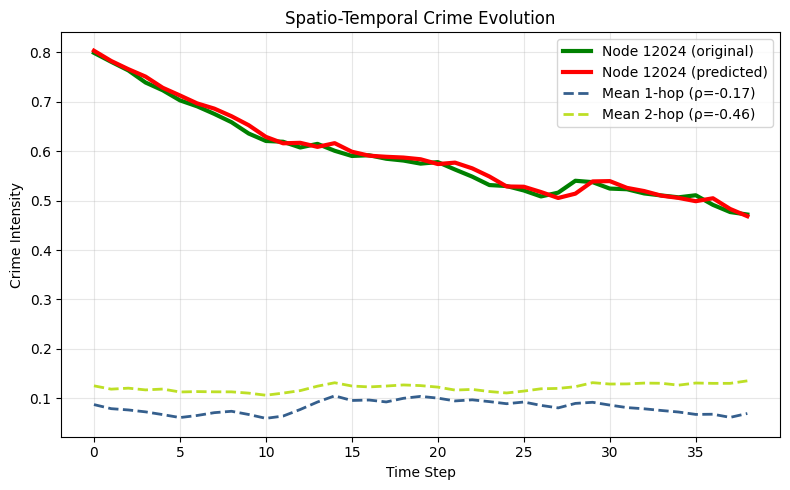

In [55]:
adj = build_adj(edge_index)
pred_matrix = np.stack(preds_per_t)
target_mat = np.stack(targets_per_t)
selected_node = 12024
plot_fluctuation_analysis(pred_matrix, target_mat, selected_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'node_{selected_node}_evolution_{model_used}')


## Choose High Crime Node

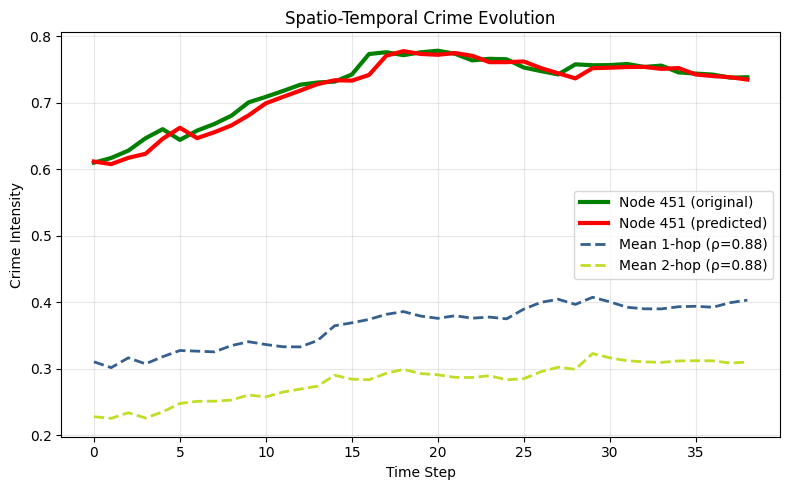

In [32]:
adj = build_adj(edge_index)
pred_matrix = np.stack(preds_per_t)
target_mat = np.stack(targets_per_t)

# Choose high-crime node
avg_pred_per_node = pred_matrix.mean(axis=0)
high_node = np.argmax(avg_pred_per_node)

neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(high_node, adj, 2)

plot_fluctuation_analysis(pred_matrix, target_mat, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_high_crime_node_{high_node}')


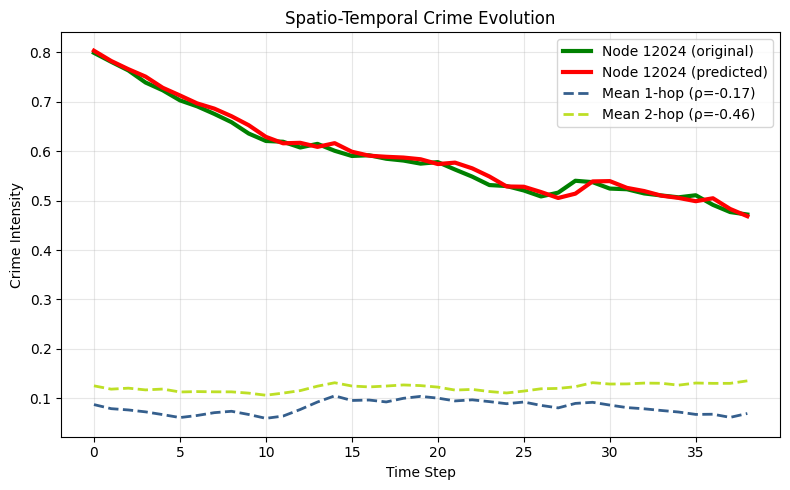

In [33]:
adj = build_adj(edge_index)
pred_matrix = np.stack(preds_per_t)

# Choose high-crime node
avg_pred_per_node = pred_matrix.mean(axis=0)
# high_node = np.argmax(avg_pred_per_node)

high_node = 12024

neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(high_node, adj, 2)

plot_fluctuation_analysis(pred_matrix, target_mat, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_high_crime_node_{high_node}')


In [34]:
corr = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_1].mean(axis=1)
)[0,1]

corr_2 = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_2].mean(axis=1)
)[0,1]

print("Correlation with 1-hop neighbors:", corr)
print("Correlation with 2-hop neighbors:", corr_2)


Correlation with 1-hop neighbors: -0.16822005705995607
Correlation with 2-hop neighbors: -0.45502729719692203


## Find Peak valley

In [35]:
def find_peak_valley_peak_node(pred_matrix):
    T, N = pred_matrix.shape
    
    scores = []

    for n in range(N):
        series = pred_matrix[:, n]
        
        first_third = series[:T//3].max()
        middle_third = series[T//3:2*T//3].min()
        last_third = series[2*T//3:].max()
        
        score = (first_third + last_third) - middle_third
        scores.append(score)
    
    return np.argmax(scores)


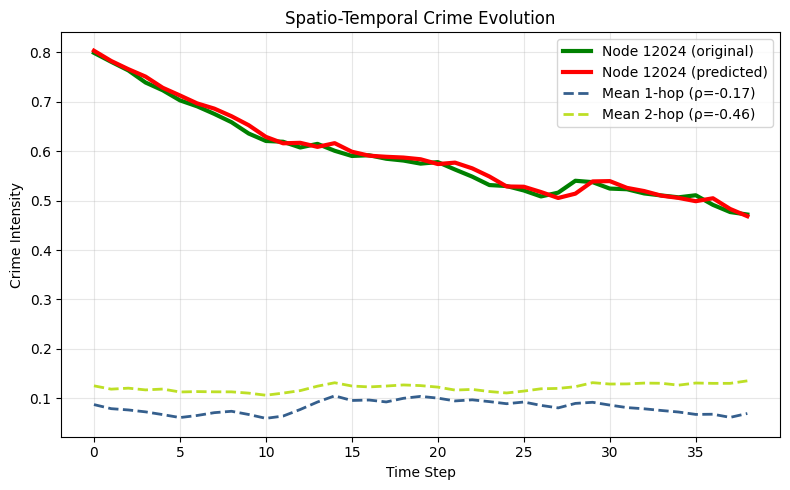

In [36]:
pred_matrix = np.stack(preds_per_t)

high_node = find_peak_valley_peak_node(pred_matrix)

neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(high_node, adj, 2)

plot_fluctuation_analysis(pred_matrix, target_mat, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_peak_valley_node_{high_node}')



In [37]:
corr = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_1].mean(axis=1)
)[0,1]

corr_2 = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_2].mean(axis=1)
)[0,1]

print("Correlation with 1-hop neighbors:", corr)
print("Correlation with 2-hop neighbors:", corr_2)


Correlation with 1-hop neighbors: -0.16822005705995607
Correlation with 2-hop neighbors: -0.45502729719692203


## Fluctuation by curvature

In [38]:
def fluctuation_by_curvature(pred_matrix):
    T, N = pred_matrix.shape
    curvature_scores = np.zeros(N)

    for n in range(N):
        series = pred_matrix[:, n]
        second_derivative = np.diff(series, n=0)
        curvature_scores[n] = np.sum(np.abs(second_derivative))

    return np.argmax(curvature_scores)


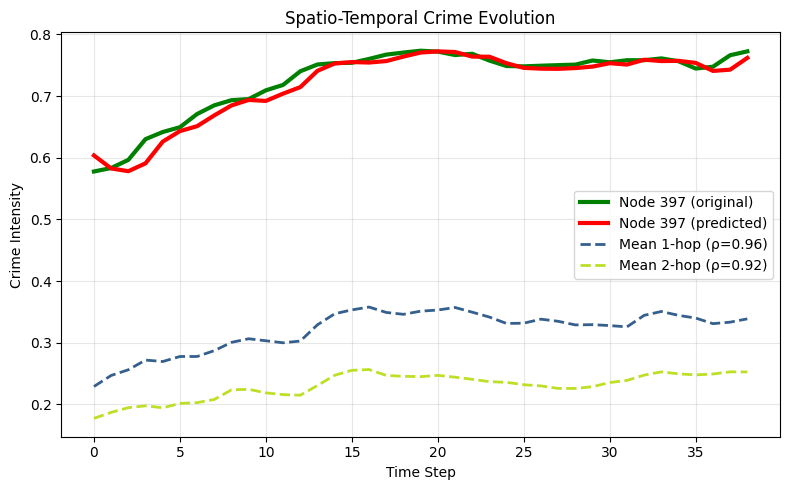

In [39]:
pred_matrix = np.stack(preds_per_t)

# node_2 = find_clean_fluctuation_node(pred_matrix)
high_node = fluctuation_by_curvature(pred_matrix)
high_node = 397 #5649

plot_fluctuation_analysis(pred_matrix, target_mat, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_fluctuation_curvature_node_{high_node}')




In [40]:
corr = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_1].mean(axis=1)
)[0,1]

corr_2 = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_2].mean(axis=1)
)[0,1]

print("Correlation with 1-hop neighbors:", corr)
print("Correlation with 2-hop neighbors:", corr_2)


Correlation with 1-hop neighbors: 0.47260267378680193
Correlation with 2-hop neighbors: 0.4011081381101012


# Modality Contribution

## Ablation approach

In [41]:
# full_loss = evaluate_regression(model, test_loader,"cpu")
# full_loss, _,_ = evaluate_and_collect(model, test_loader,device = "cpu")
static_only_loss = ablation_evaluate(model, test_loader, criterion, mode="static")
dynamic_only_loss = ablation_evaluate(model, test_loader, criterion, mode="dynamic")
print("Ablation results:")

print(f"Full model      : {metrics['MSE']:.4f}")
print(f"Static only     : {static_only_loss:.4f}")
print(f"Dynamic only    : {dynamic_only_loss:.4f}")


Ablation results:
Full model      : 0.0001
Static only     : 0.0038
Dynamic only    : 0.0001


In [42]:
import pandas as pd

# Create results table
results = pd.DataFrame({
    "Model": ["Full model", "Static only", "Dynamic only"],
    "MSE": [
        metrics["MSE"],
        static_only_loss,
        dynamic_only_loss
    ]
})

# Save to CSV
results.to_csv(f"{output_folder}/ablation_results_{model_used}.csv", index=False)

print("Saved to ablation_results.csv")

Saved to ablation_results.csv


In [43]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(len(alpha_self_history))


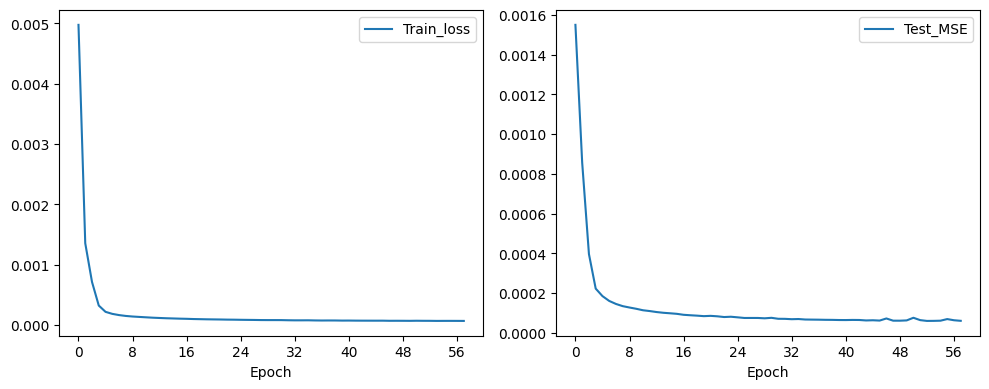

In [44]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_per_epoch, label="Train_loss")
# plt.plot(epochs, [1 - a for a in alpha_self_history], label="Dynamic", linestyle="--")
# plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
# plt.title("Self Contribution")
plt.xlabel("Epoch")
# plt.ylabel("Weight")
plt.legend()
# plt.grid(True)

plt.subplot(1, 2, 2)
mse_values = [d['MSE'] for d in test_loss_per_epoch]
plt.plot(epochs, mse_values, label="Test_MSE")
# plt.plot(epochs, [1 - a for a in alpha_neigh_history], label="Dynamic", linestyle="--")

# plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
# plt.title("Neighbor Contribution")
plt.xlabel("Epoch")
plt.legend()
# plt.grid(True)

plt.tight_layout()
output_path = output_folder 
if output_path:
    file_path = os.path.join(output_path, f"Train_test_Loss_{model_used}.{save_format}")
    plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plt.show()
    plt.close()


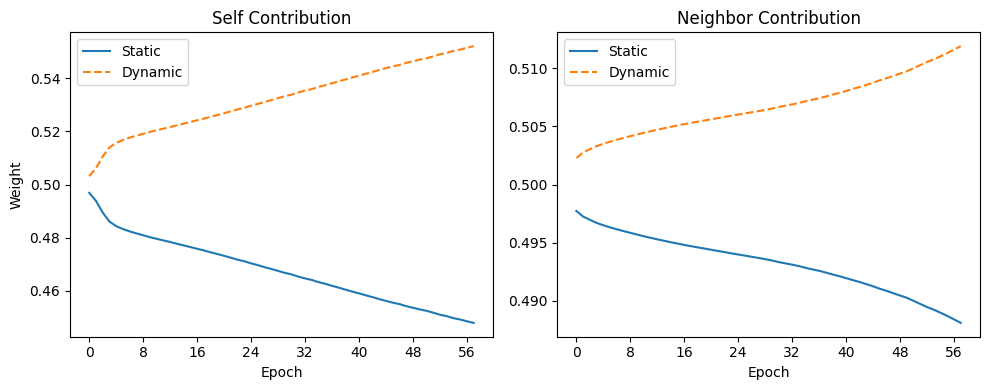

In [45]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, alpha_self_history, label="Static")
plt.plot(epochs, [1 - a for a in alpha_self_history], label="Dynamic", linestyle="--")
# plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
plt.title("Self Contribution")
plt.xlabel("Epoch")
plt.ylabel("Weight")
plt.legend()
# plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, alpha_neigh_history, label="Static")
plt.plot(epochs, [1 - a for a in alpha_neigh_history], label="Dynamic", linestyle="--")

# plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
plt.title("Neighbor Contribution")
plt.xlabel("Epoch")
plt.legend()
# plt.grid(True)

plt.tight_layout()
# plt.show()
output_path = output_folder 
if output_path:
    file_path = os.path.join(output_path, f"contribution_zoom_{model_used}.{save_format}")
    plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plt.show()
    plt.close()


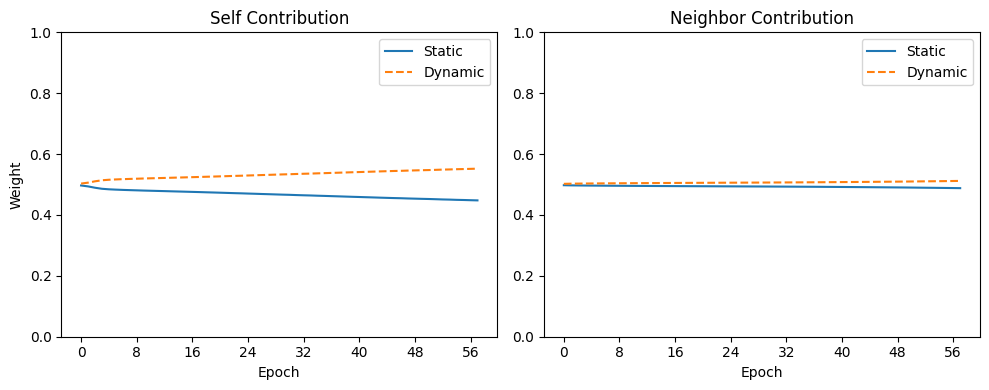

In [46]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, alpha_self_history, label="Static")
plt.plot(epochs, [1 - a for a in alpha_self_history], label="Dynamic", linestyle="--")
plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
plt.title("Self Contribution")
plt.xlabel("Epoch")
plt.ylabel("Weight")
plt.legend()
# plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, alpha_neigh_history, label="Static")
plt.plot(epochs, [1 - a for a in alpha_neigh_history], label="Dynamic", linestyle="--")

plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
plt.title("Neighbor Contribution")
plt.xlabel("Epoch")
plt.legend()
# plt.grid(True)

plt.tight_layout()
output_path = output_folder 
if output_path:
    file_path = os.path.join(output_path, f"contribution_{model_used}.{save_format}")
    plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plt.show()
    plt.close()


# Embedding projection

In [47]:
x_dynamic_window = test_dataset.x_dynamic[:, -3:]  # last 3 months

model.eval()
_, embeddings = model(
    test_dataset.x_static,
    x_dynamic_window,
    test_dataset.edge_index,
    return_embedding=True
)
print(f"Node Embeddings shape: {embeddings.shape}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (55234x3 and 5x64)

In [ ]:
tsne = TSNE(n_components=2, random_state=seed)
emb_2d = tsne.fit_transform(embeddings.detach().cpu().numpy())

tsne_result = pd.DataFrame(emb_2d)
tsne_result.to_csv(f"{output_folder}/tsne_output_{model_used}_{type_graph_conv}_{architecture}.csv", index=False)

In [ ]:
tsne = TSNE(n_components=2, random_state=seed)
emb_2d = tsne.fit_transform(embeddings.detach().cpu().numpy())

tsne_result = pd.DataFrame(emb_2d)
tsne_result.to_csv(f"{output_folder}/tsne_output_{model_used}_{type_graph_conv}_{architecture}.csv", index=False)

In [ ]:
def plot_embedding(emb_2d, filename= 'embedding', output_path = None):
    df_emb = pd.DataFrame(emb_2d, columns=['x', 'y'])

    plt.figure(figsize=figsize)
    sns.scatterplot(data=df_emb, x='x', y='y', palette='Set1')
    # Save or show
    if output_path:
        file_path = os.path.join(output_path, f"{filename}.{save_format}")
        plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        plt.show()
        plt.close()

In [ ]:
def plot_embedding_label(emb_2d, crime_label_tensor, filename= 'embedding', output_path = None):
    df_emb = pd.DataFrame(emb_2d, columns=['x', 'y'])
    df_emb['label'] = crime_label_tensor

    plt.figure(figsize=figsize)
    sns.scatterplot(data=df_emb, x='x', y='y', hue='label', palette='Set1')
    # Save or show
    if output_path:
        file_path = os.path.join(output_path, f"{filename}.{save_format}")
        plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        plt.show()
        plt.close()

C:\Users\waqar\AppData\Local\Temp\ipykernel_42068\2259634616.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_emb, x='x', y='y', palette='Set1')


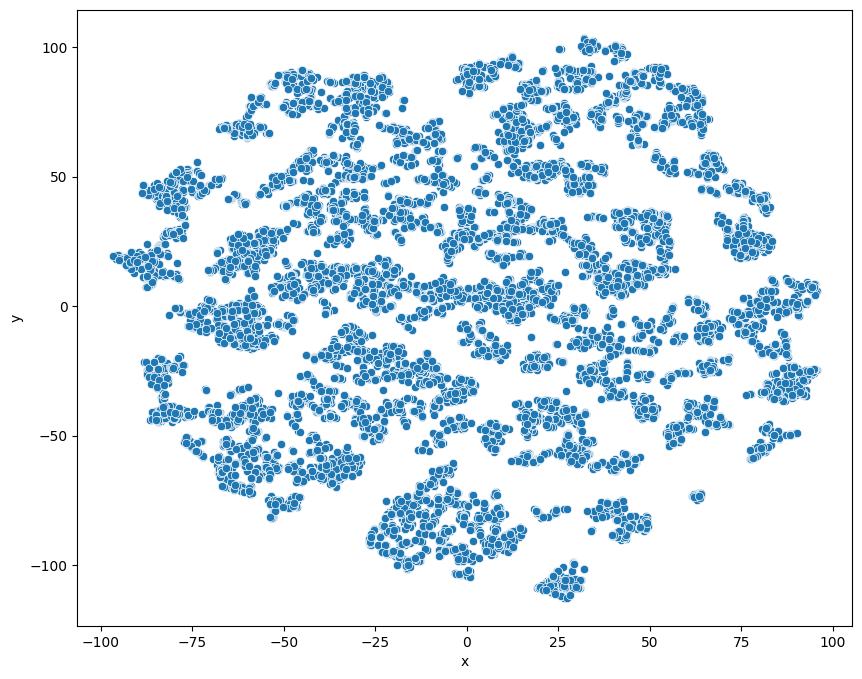

In [ ]:
plot_embedding(emb_2d, filename= f'embedding_{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)

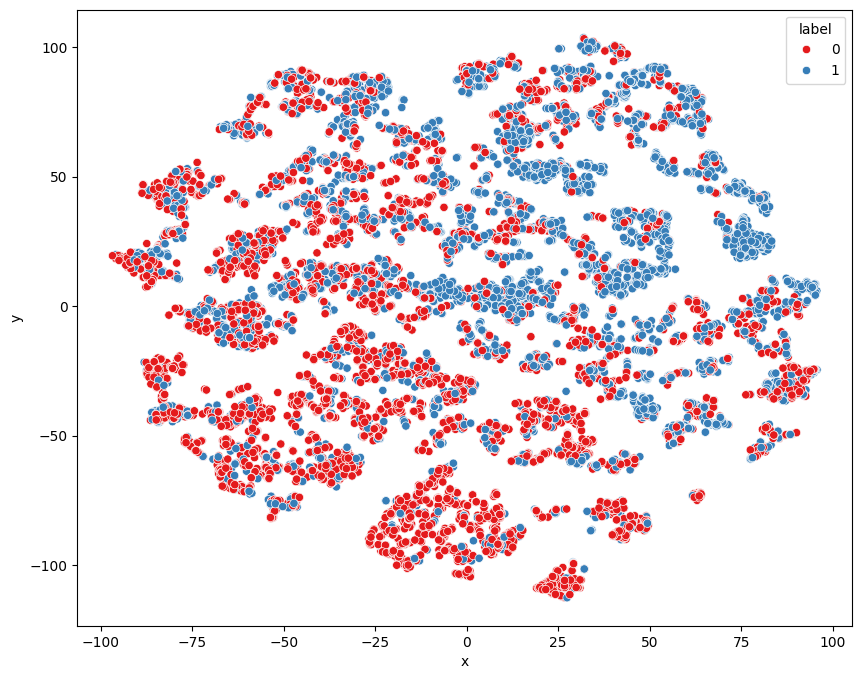

In [ ]:
plot_embedding_label(emb_2d, crime_label_col, filename= f'embedding_with_label_{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)
